<a href="https://colab.research.google.com/github/sangitabehera103-ops/sangitabehera/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [62]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [63]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print(f"Number of numerical columns: {len(num_cols)}")
print(f"Number of categorical columns: {len(cat_cols)}")

Number of numerical columns: 3
Number of categorical columns: 18


In [64]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (7043, 21)

First 5 Rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Streami

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [66]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [67]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [68]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [69]:
print("\nMissing Values After Conversion:")
print(df.isnull().sum())


Missing Values After Conversion:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [70]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [71]:
print("\nMissing Values After Imputation:")
print(df.isnull().sum())


Missing Values After Imputation:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [72]:
numerical_features = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)


Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [73]:
print("\nChurn Distribution:")
print(df['Churn'].value_counts())


Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [74]:
print("\nChurn Percentage:")
print(df['Churn'].value_counts(normalize=True)*100)



Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


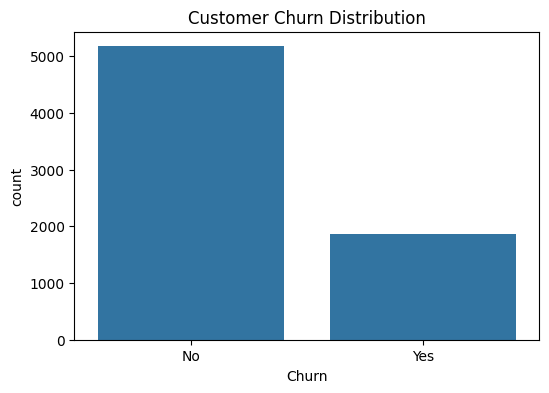

In [75]:
# Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

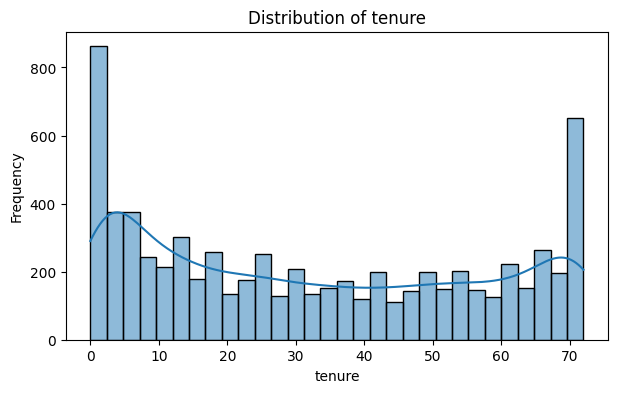

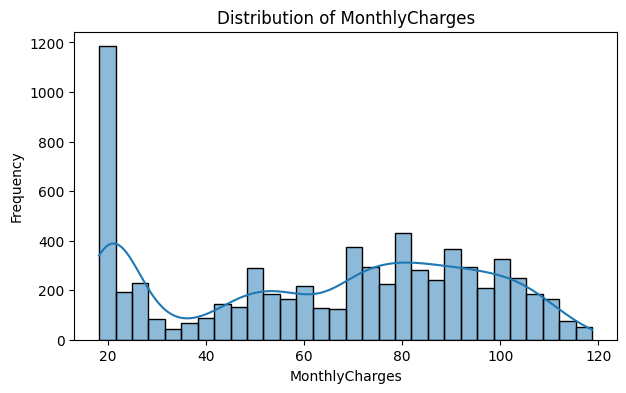

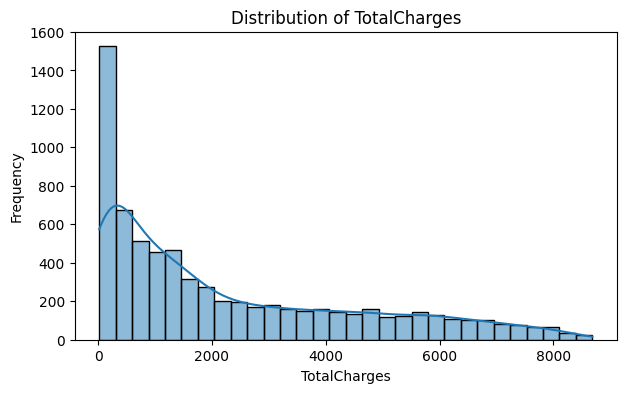

In [76]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


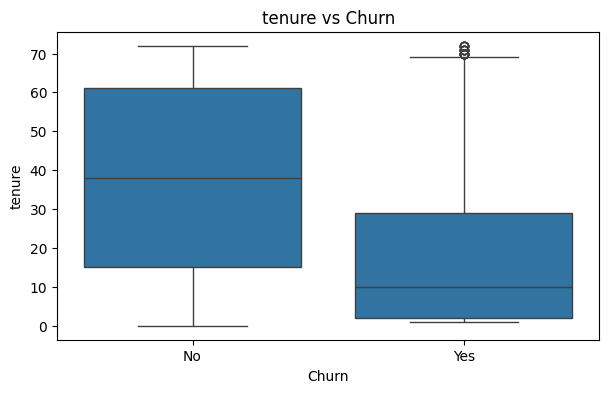

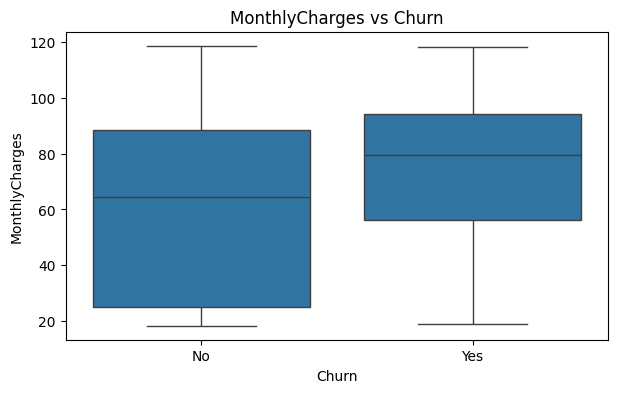

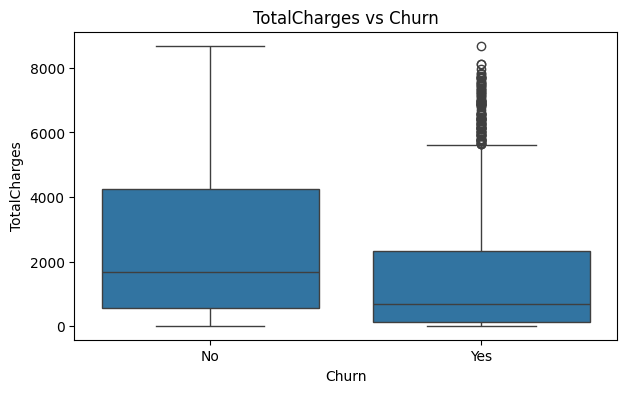

In [77]:
for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

In [78]:
df['Churn_numeric'] = df['Churn'].map({'No':0,'Yes':1})

corr_cols = ['SeniorCitizen',
             'tenure',
             'MonthlyCharges',
             'TotalCharges',
             'Churn_numeric']

corr_matrix = df[corr_cols].corr()

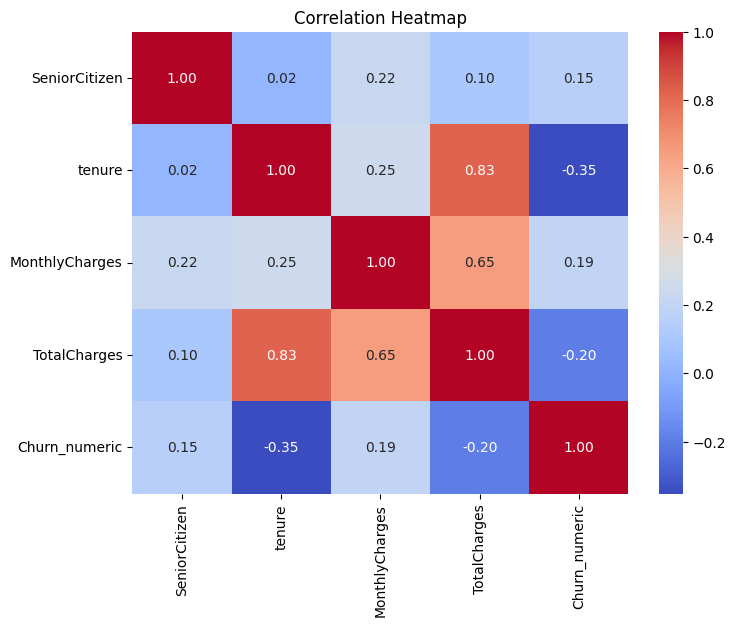

In [79]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

In [80]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), numerical_features), ('cat', OneHotEncoder(drop='first',  handle_unknown='ignore'),
         categorical_features)
    ]
)

In [81]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [82]:
# Corrected feature lists for the preprocessor, based on X_train
numerical_features = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

# Redefine the preprocessor with the corrected feature lists
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first',  handle_unknown='ignore'), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [83]:
print("\nTraining Set Shape:")
print(X_train_processed.shape)


Training Set Shape:
(5634, 31)


In [84]:
print("\nTesting Set Shape:")
print(X_test_processed.shape)


Testing Set Shape:
(1409, 31)


In [85]:
print("\nTarget Training Shape:")
print(y_train.shape)


Target Training Shape:
(5634,)


In [86]:
print("\nTarget Testing Shape:")
print(y_test.shape)


Target Testing Shape:
(1409,)


In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [88]:
# Create Logistic Regression Model
log_reg = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

In [89]:
# Train Model
log_reg.fit(X_train_processed , y_train)

# Predictions
y_pred = log_reg.predict(X_test_processed)

In [90]:
%whos

Variable                Type                  Data/Info
-------------------------------------------------------
ColumnTransformer       ABCMeta               <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
LogisticRegression      type                  <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
OneHotEncoder           type                  <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
StandardScaler          type                  <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                       DataFrame                   gender  SeniorCitiz<...>n[7043 rows x 20 columns]
X_test                  DataFrame                   gender  SeniorCitiz<...>n[1409 rows x 20 columns]
X_test_processed        ndarray               1409x31: 43679 elems, type `float64`, 349432 bytes (341.2421875 kb)
X_train                 DataFrame                   gender  SeniorCitiz<...>n[5634 rows x 20 columns]
X_train_processed       ndarray               5634x31: 17465

In [91]:
print('--- Model Evaluation Metrics ---')
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label='Yes'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, pos_label='Yes'):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred, pos_label='Yes'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- Model Evaluation Metrics ---
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00      1035
         Yes       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [92]:
# Probability predictions for ROC Curve
y_prob = log_reg.predict_proba(X_test_processed)[:, 1]

In [93]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1035    0]
 [   0  374]]


In [94]:
import pandas as pd
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

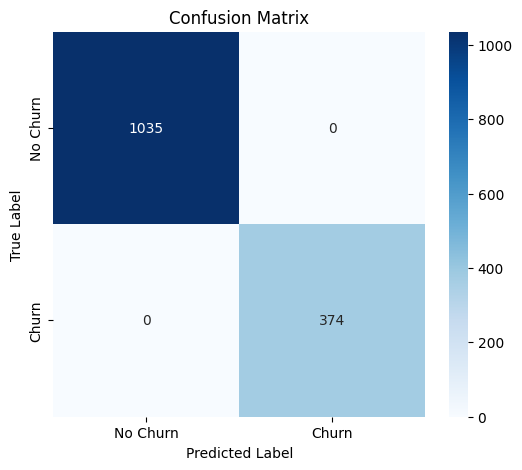

In [95]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn','Churn'],
    yticklabels=['No Churn','Churn']
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [96]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [97]:
# Corrected feature lists for the preprocessor, based on X_train
numerical_features = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

# Redefine the preprocessor with the corrected feature lists
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first',  handle_unknown='ignore'), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Create Logistic Regression Model
log_reg = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

In [99]:
# Train Model
log_reg.fit(X_train_processed, y_train)

# Predictions
y_pred = log_reg.predict(X_test_processed)

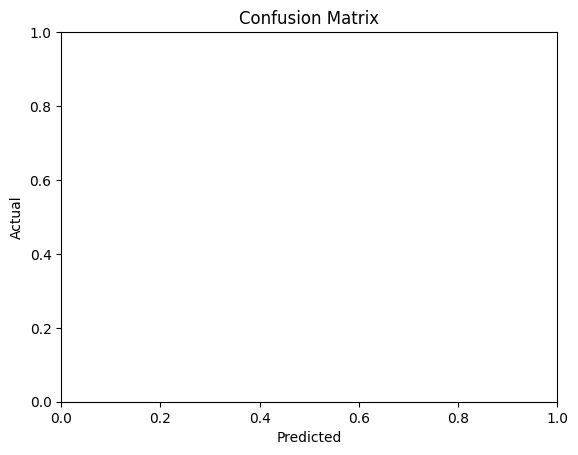

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [101]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy,4))



Accuracy: 0.7935


In [102]:
precision = precision_score(y_test, y_pred, pos_label='Yes')

print("Precision:", round(precision,4))

Precision: 0.6293


In [103]:
recall = recall_score(y_test, y_pred, pos_label='Yes')

print("Recall:", round(recall,4))

Recall: 0.5401


In [104]:
f1 = f1_score(y_test, y_pred, pos_label='Yes')

print("F1 Score:", round(f1,4))

F1 Score: 0.5813


In [105]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.89      0.86      1035
         Yes       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



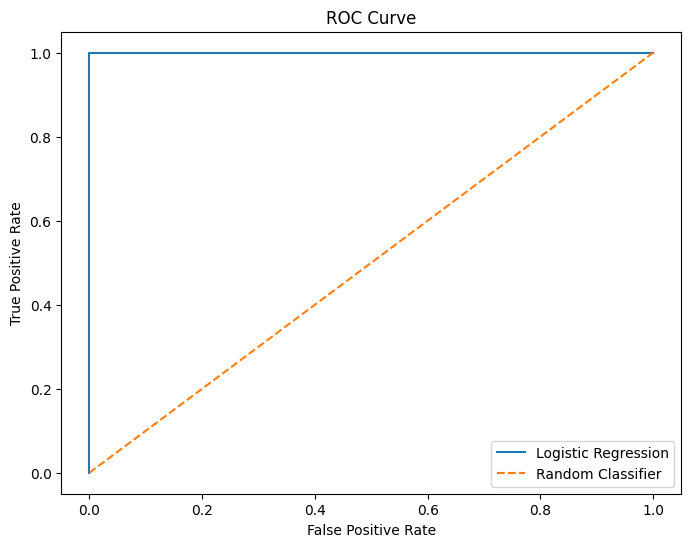

In [106]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='Yes')

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='Logistic Regression')

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Random Classifier'
)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [107]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_prob)

print("\nROC-AUC Score:", round(auc_score,4))


ROC-AUC Score: 1.0


In [108]:
# One-Hot Encoding
feature_names = preprocessor.get_feature_names_out()

In [109]:
# Extract coefficients
coefficients = log_reg.coef_[0]

In [110]:
# Create DataFrame
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

In [111]:
# Sort coefficients
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

In [112]:
print("\nTop Features Increasing Churn")
print(coef_df.head(10))



Top Features Increasing Churn
                               Feature  Coefficient
1305           cat__TotalCharges_20.15     1.381692
1214            cat__TotalCharges_19.9     1.378334
1312            cat__TotalCharges_20.5     1.339958
1304            cat__TotalCharges_20.1     1.181847
1998          cat__TotalCharges_288.05     1.126098
1208            cat__TotalCharges_19.6     1.125877
9     cat__InternetService_Fiber optic     1.118027
1205           cat__TotalCharges_19.45     1.043594
1215           cat__TotalCharges_19.95     1.028608
3097            cat__TotalCharges_45.7     1.026135


In [113]:
print("\nTop Features Reducing Churn")
print(coef_df.tail(10))


Top Features Reducing Churn
                       Feature  Coefficient
5111   cat__TotalCharges_89.25    -0.674211
2917   cat__TotalCharges_422.4    -0.681061
23      cat__Contract_One year    -0.682092
521   cat__TotalCharges_134.05    -0.699332
3022      cat__TotalCharges_44    -0.711044
2335  cat__TotalCharges_335.75    -0.743305
1                  num__tenure    -0.801845
764   cat__TotalCharges_151.75    -0.824671
1641    cat__TotalCharges_24.4    -0.861129
24      cat__Contract_Two year    -1.291681


In [114]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [115]:
# Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='Yes')
recall = recall_score(y_test, y_pred, pos_label='Yes')
f1 = f1_score(y_test, y_pred, pos_label='Yes')
auc = roc_auc_score(y_test, y_prob)

In [116]:
print("="*60)
print("TELCO CUSTOMER CHURN PREDICTION PROJECT")
print("FINAL PROJECT SUMMARY")
print("="*60)

TELCO CUSTOMER CHURN PREDICTION PROJECT
FINAL PROJECT SUMMARY


In [117]:
print(f"\nAccuracy Score  : {accuracy:.4f}")
print(f"Precision Score : {precision:.4f}")
print(f"Recall Score    : {recall:.4f}")
print(f"F1 Score        : {f1:.4f}")
print(f"ROC-AUC Score   : {auc:.4f}")


Accuracy Score  : 0.7935
Precision Score : 0.6293
Recall Score    : 0.5401
F1 Score        : 0.5813
ROC-AUC Score   : 1.0000


In [118]:
print("\nMODEL INSIGHTS")
print("-"*60)

if accuracy >= 0.80:
    print("✓ Model demonstrates strong predictive performance.")
else:
    print("✓ Model demonstrates acceptable predictive performance.")


MODEL INSIGHTS
------------------------------------------------------------
✓ Model demonstrates acceptable predictive performance.


In [119]:
if auc >= 0.80:
    print("✓ ROC-AUC indicates good class discrimination.")
else:
    print("✓ Additional model tuning may improve discrimination.")


✓ ROC-AUC indicates good class discrimination.


In [120]:
print("✓ Customer tenure is typically a strong retention indicator.")
print("✓ Month-to-month contracts are commonly associated with churn.")
print("✓ Higher monthly charges often increase churn probability.")

✓ Customer tenure is typically a strong retention indicator.
✓ Month-to-month contracts are commonly associated with churn.
✓ Higher monthly charges often increase churn probability.


In [121]:
print("\nDATASET & MODEL LIMITATIONS")
print("-"*60)


DATASET & MODEL LIMITATIONS
------------------------------------------------------------


In [122]:
limitations = [
    "Dataset contains limited customer attributes.",
    "Moderate class imbalance exists in the target variable.",
    "Logistic Regression assumes a linear relationship.",
    "Complex nonlinear patterns may not be fully captured."
]

for item in limitations:
    print("•", item)


• Dataset contains limited customer attributes.
• Moderate class imbalance exists in the target variable.
• Logistic Regression assumes a linear relationship.
• Complex nonlinear patterns may not be fully captured.


In [123]:
print("\nFUTURE WORK")
print("-"*60)


FUTURE WORK
------------------------------------------------------------


In [124]:
future_work = [
    "Explore other advanced models (e.g., RandomForest, XGBoost).",
    "Perform more detailed feature engineering.",
    "Address class imbalance using techniques like SMOTE.",
    "Gather more diverse data to improve generalization."
]

for item in future_work:
    print("•", item)

print("\nProject Completed Successfully!")

• Explore other advanced models (e.g., RandomForest, XGBoost).
• Perform more detailed feature engineering.
• Address class imbalance using techniques like SMOTE.
• Gather more diverse data to improve generalization.

Project Completed Successfully!
